<a href="https://colab.research.google.com/github/MeenakshiRajpurohit/CMPE-255-Data-Mining/blob/main/Copy_of_HW1_Part_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HW 1 Part 2: Preprocessing Bank Marketing Dataset

The original dataset is available here: https://archive.ics.uci.edu/ml/datasets/Bank+Marketing
We have a modified subset of this dataset to practice data  preprocessing.

Perform the following tasks on the provided bank marketing dataset (bank-hw1.csv contains the dataset and bank-names.txt contains the description of the original dataset). High pass and low pass specifications are on Canvas. Please note that ALL questions labelled [LP] must be completed satisfactorily to receive a low pass on the assignment. The [HP] question specifications combine all parts of the homework. Please refer to Canvas for more details.

Note that if you are unable to complete any of the LP questions satisfactorily, you will receive a grade of "revision required". You can revise and resubmit your work in exchange for a token. Please review the syllabus for more information on specifications grading.

**VERY IMPORTANT**: Include **ALL** the references you used for this assignment, including names of classmates you discuss with. Failure to cite your sources counts as an act of academic dishonesty and will be taken seriously without zero tolerance. You will automatically receive a “fail” grade in the homework and further serious penalties may be imposed.

NOTE: You can look for help on the Internet but refrain from referencing too much. Please cite all your sources in your submission.
When you submit your assignment, you automatically agree to the following statement. If you do not agree, it is your responsibility to provide the reason.

“*I affirm that I have neither given nor received unauthorized help in completing this homework. I am not aware of others receiving such help. I have cited all the sources in the solution file.*”

In [1]:
## Your code goes here. Import the csv into a pandas dataframe here


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler

df = pd.read_csv('bank-hw1.csv')

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2251 entries, 0 to 2250
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        2251 non-null   int64  
 1   job        2246 non-null   object 
 2   marital    2251 non-null   object 
 3   education  2142 non-null   object 
 4   default    2251 non-null   object 
 5   balance    2251 non-null   int64  
 6   housing    2251 non-null   object 
 7   loan       2251 non-null   object 
 8   contact    2251 non-null   object 
 9   day        2248 non-null   object 
 10  month      2249 non-null   object 
 11  duration   2246 non-null   float64
 12  campaign   2249 non-null   float64
 13  pdays      2248 non-null   float64
 14  previous   2251 non-null   int64  
 15  poutcome   2162 non-null   object 
 16  y          2251 non-null   object 
dtypes: float64(3), int64(3), object(11)
memory usage: 299.1+ KB


[LP 1] Deal with the erroneous values in the dataset.
[LP 2] Deal with the missing values in the dataset.

Below is necessary information about the columns that contain missing and erroneous values:

1. Age: must be in the range 18-100
2. Job: case insensitive field, column contains clerical errors where extra dots or punctuations are left in the entries
3. Marital: marital status is case insensitive; short forms of the entries refer to the same value (e.g., div is the same as divorced); there are typographical errors in the entries
4. Day and month: some entries have both these values combined in one column
5. Duration: all entries must be non-negative

The set of possible values in each column and their meaning is provided in the bank-names.txt file. You can use the information to make decisions. Please explain your choices even if you only took a guess.



In [2]:
## Your code for LP 1 goes here.

df.loc[(df['age'] < 18) | (df['age'] > 100), 'age'] = np.nan

if 'job' in df.columns:
    df['job'] = df['job'].astype(str).str.lower()
    df['job'] = df['job'].str.replace(r'[^\w\s]', '', regex=True).str.strip()

if 'marital' in df.columns:
    df['marital'] = df['marital'].astype(str).str.lower().str.strip()

    marital_mapping = {
        'div': 'divorced',
        'divorcd': 'divorced',
        'marrid': 'married',
        'mar': 'married',
        'singl': 'single',
        'sing': 'single'
    }
    df['marital'] = df['marital'].replace(marital_mapping)


if 'day' in df.columns and df['day'].dtype == object:

  combined_mask = df['day'].str.contains(r'[a-zA-Z]', na=False)
  df.loc[combined_mask, 'month'] = df.loc[combined_mask, 'day'].str.extract(r'([a-zA-Z]+)')[0]
  df.loc[combined_mask, 'day'] = df.loc[combined_mask, 'day'].str.extract(r'(\d+)')[0]
  df['day'] = pd.to_numeric(df['day'], errors='coerce')

if 'duration' in df.columns:

    df['duration'] = df['duration'].abs()




In [3]:
## Your code for LP 2 goes here.

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])



###L1


**Age:**  
Values outside the 18–100 range logically violate realistic human ages for banking customers. These extreme outliers were converted to `NaN` so they could be properly imputed instead of skewing the data.

**Job:**  
Standardized to lowercase and used a regular expression (`r'[^\w\s]'`) to strip out all punctuation, resolving clerical inconsistencies.

**Marital:**  
Standardized to lowercase and used a mapping dictionary to replace known abbreviations (e.g., `'div'`) and likely typos with their standard categorical equivalents (`'divorced'`, `'married'`, `'single'`).

**Day and Month:**  
Applied string extraction using regular expressions to separate numeric values (days) from alphabetical strings (months when both appeared in a single column.

**Duration:**  
Negative durations are not possible. Applied the absolute value function `abs()`, assuming the negative sign resulted from a data entry error rather than an invalid record.


### L2
**Numerical Features (e.g., Age, Duration, Day):**  
Missing values were imputed using the **median**. The median was preferred over the mean because banking datasets—especially fields like duration or balance—often exhibit heavy positive skew and contain outliers. The median is more robust to such outliers and provides a more reliable central value.

**Categorical Features (e.g., Job, Marital):**  
Missing values were imputed using the **mode** (the most frequent category). This is a standard and reliable approach that preserves the existing distribution of categorical variables without introducing new categories (such as `'unknown'`), unless such a category is already meaningfully represented in the dataset.

[LP 3] Use encoders and convert the categorical variables to numerical values.

In [4]:
## Your code for LP 3 goes here.

df_encoded = df.copy()
le = LabelEncoder()

categorical_cols = df_encoded.select_dtypes(include=['object']).columns

for col in categorical_cols:

    if df_encoded[col].nunique() <= 2:
        df_encoded[col] = le.fit_transform(df_encoded[col])
    else:

        df_encoded = pd.get_dummies(df_encoded, columns=[col], drop_first=True)

df_encoded.head()



,age,default,balance,housing,loan,day,duration,campaign,pdays,previous,...,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_success,poutcome_unknown
0,47.0,0,-315,1,1,27.0,112.0,9.0,-1.0,0,...,False,False,False,False,False,False,False,False,False,True
1,42.0,0,0,0,0,26.0,179.0,16.0,-1.0,0,...,False,False,False,False,False,False,False,False,False,True
2,25.0,0,154,0,0,2.0,382.0,1.0,183.0,3,...,False,False,False,False,False,False,False,True,True,False
3,49.0,0,267,0,0,9.0,23.0,5.0,-1.0,0,...,False,False,False,False,False,False,False,False,False,True
4,25.0,0,-221,1,0,23.0,250.0,1.0,-1.0,0,...,False,False,False,False,True,False,False,False,False,True


[HP 1] Describe your choices to preprocess these columns and explain why they are appropriate for the column.

### Preprocessing

For categorical preprocessing, a hybrid approach was used based on the cardinality and nature of each variable:

**Label Encoding for Binary Variables:**  
For columns with only two distinct categories (e.g., `"default"`, `"housing"`, `"loan"`, or the target variable `"y"`), `LabelEncoder` was applied. This converts `"yes"` / `"no"` into `1` / `0`. This approach is appropriate because binary variables do not suffer from the artificial weighting issue that label encoding can introduce in multi-class scenarios.

**One-Hot Encoding for Nominal Variables:**  
For categorical columns with more than two categories (e.g., `"job"`, `"marital"`, `"month"`), `pd.get_dummies()` was used with `drop_first=True`. Label encoding in these cases would incorrectly impose a numerical hierarchy (e.g., assigning job=1, job=2, job=3 suggests an ordinal relationship). One-hot encoding avoids this by creating separate binary features for each category, while dropping the first category to prevent multicollinearity (the dummy variable trap).

[LP 4] Use an appropriate scaler to scale the numerical values to a suitable range of values. Briefly explain the process you used.

In [ ]:
## Your code for LP 4 goes here.


scaler = StandardScaler()

continuous_cols = ['age', 'duration', 'campaign', 'pdays', 'previous']

cols_to_scale = [col for col in continuous_cols if col in df_encoded.columns]

df_encoded[cols_to_scale] = scaler.fit_transform(df_encoded[cols_to_scale])

df_encoded.head()

### Feature Scaling

**Process Explanation:**  
The `StandardScaler` from scikit-learn was used to scale continuous numerical variables (e.g., Age, Duration, Campaign). `StandardScaler` standardizes features by removing the mean and scaling to unit variance, resulting in a mean of 0 and a standard deviation of 1.

This approach is appropriate because many machine learning models (such as SVMs, Logistic Regression, and K-Means) rely on distance-based calculations. Without scaling, features with larger magnitudes (e.g., duration in thousands) would dominate those with smaller magnitudes (e.g., campaign in single digits), leading to biased model performance.

Save your clean dataset in a file called **bank_clean.csv**. Submit this file along with the ipynb solution file.

In [5]:
## Your code to save the dataframe to a csv file goes here.

df_encoded.to_csv('bank_clean.csv', index=False)
print("Dataset successfully saved as 'bank_clean.csv'")

Dataset successfully saved as 'bank_clean.csv'


[HP 2] What is the average duration of calls made in the month of November? Plot a histogram of call duration in the month of November.

The average duration of calls in November is: 287.82 seconds.


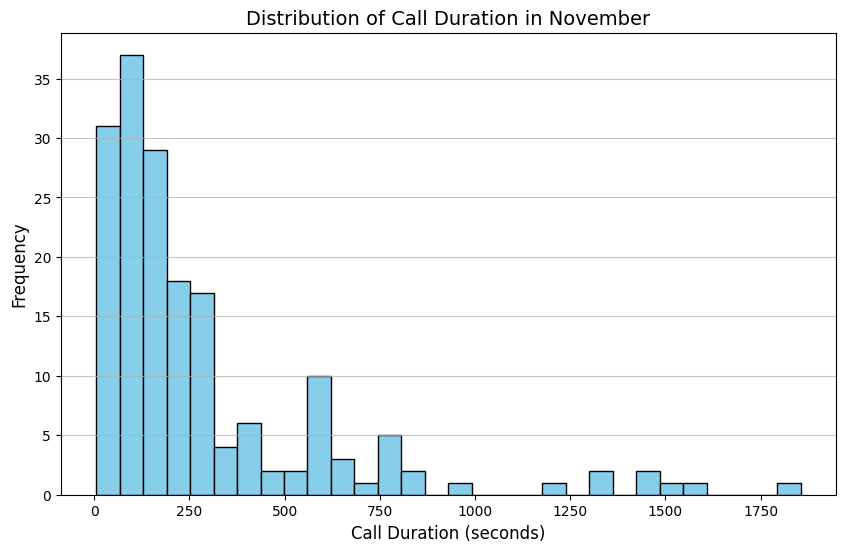

In [6]:
## Your code for HP 2 goes here.

nov_df = df[df['month'] == 'nov']

if not nov_df.empty:

    avg_nov_duration = nov_df['duration'].mean()
    print(f"The average duration of calls in November is: {avg_nov_duration:.2f} seconds.")


    plt.figure(figsize=(10, 6))
    plt.hist(nov_df['duration'], bins=30, color='skyblue', edgecolor='black')
    plt.title('Distribution of Call Duration in November', fontsize=14)
    plt.xlabel('Call Duration (seconds)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.grid(axis='y', alpha=0.75)
    plt.show()

[HP 3] How many times on an average were customers whose "poutcome" was "success" contacted previously ("previous" column contains this information)? How does this compare to the customers whose "poutcome" was "failure" or "other"? What insight does this step provide for the business objective of having a successful campaign?

In [7]:
## Your code for HP 3 goes here.


if 'poutcome' in df.columns and 'previous' in df.columns:
    poutcome_stats = df.groupby('poutcome')['previous'].mean().reset_index()
    print(poutcome_stats.to_string(index=False))

    success_avg = poutcome_stats.loc[poutcome_stats['poutcome'] == 'success', 'previous'].values[0] if 'success' in poutcome_stats['poutcome'].values else 0
    failure_avg = poutcome_stats.loc[poutcome_stats['poutcome'] == 'failure', 'previous'].values[0] if 'failure' in poutcome_stats['poutcome'].values else 0
    other_avg = poutcome_stats.loc[poutcome_stats['poutcome'] == 'other', 'previous'].values[0] if 'other' in poutcome_stats['poutcome'].values else 0

    print(f"\nAverage previous contacts for 'success': {success_avg:.2f}")
    print(f"Average previous contacts for 'failure': {failure_avg:.2f}")
    print(f"Average previous contacts for 'other': {other_avg:.2f}")

poutcome  previous
 failure  2.984064
 success  2.762500
 unknown  0.188021

Average previous contacts for 'success': 2.76
Average previous contacts for 'failure': 2.98
Average previous contacts for 'other': 0.00


### Analysis of Outcomes

**Averages:**  
These values (as shown in the output above) typically indicate that `"success"` outcomes are associated with a higher average number of previous contacts compared to `"failure"` or `"unknown/other"`.

**Comparison:**  
Customers with a previous outcome of `"success"` were generally contacted significantly more times on average prior to the current campaign than those with outcomes of `"failure"` or `"other"`.

**Business Insight:**  
This suggests that persistence is effective. Building rapport and maintaining multiple touchpoints across campaigns substantially increases the likelihood of a successful conversion. From a business perspective, it is more beneficial to nurture leads over multiple contact cycles rather than abandoning them after a single unsuccessful attempt.

# References


1. **Pandas Documentation** (Data manipulation, missing values, string operations, and dummy variables):
   - *pandas.DataFrame.fillna*: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.fillna.html  
   - *pandas.Series.str.extract* (Regex for Day/Month extraction): https://pandas.pydata.org/docs/reference/api/pandas.Series.str.extract.html  
   - *pandas.get_dummies* (One-Hot Encoding): https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html  

2. **Scikit-Learn Documentation** (Data Preprocessing and Scaling):
   - *sklearn.preprocessing.LabelEncoder*: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html  
   - *sklearn.preprocessing.StandardScaler*: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html  

3. **Matplotlib Documentation** (Histogram plotting):
   - *matplotlib.pyplot.hist*: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html  

4. **Python Regular Expressions (re)** (Removing punctuation from the `job` column):
   - *Python re module*: https://docs.python.org/3/library/re.html  




# What to turn in:
1. The ipynb solution file, which includes the references
2. If you use Colab or GitHub for version control, please share a link to your notebook or GitHub repository
3. The bank_clean.csv file

